# Machine Learning with scikit-learn

**Machine learning**  involves developing algorithms and statistical models that enable computers to learn from data and make predictions or decisions without being explicitly programmed. ML techniques are increasingly used in image recognition, natural language processing, autonomous vehicles, healthcare diagnostics, and more.

Machine learning tasks fall into two main categories:

- **supervised learning**:  In supervised learning, we train models on labeled data where both input features (X) and target outcomes (y) are known—the algorithm learns to map inputs to outputs. Common tasks include **regression** (predicting continuous values like house prices) and **classification** (predicting categories like email spam/not spam).

- **unsupervised learning**: In unsupervised learning, we work with unlabeled data to discover hidden patterns or structures, such as **clustering** or **dimensionality reduction** for visualization.


Throughout this course, you've developed hands-on skills in data analysis. This session will be about how to apply machine learning techniques in Python to model data it focuses exclusively on supervised learning.

## Algorithm classes

### Machine Learning Algorithm Classes

- **regression**:
  - **linear models**: Linear Regression, Ridge Regression, Lasso Regression, Elastic Net
  - **non-linear models**: Polynomial Regression, Support Vector Regression, Random Forest Regression
- **classification**:
  - **linear decision boundaries**: Logistic Regression, Linear Discriminant Analysis, Linear SVM, Naive Bayes
  - **non-linear decision boundaries**: SVM (with RBF/polynomial kernels), Decision Trees, Random Forests, Gradient Boosting, K-Nearest Neighbors
- <s> **clustering**: K-Means, DBSCAN, Hierarchical Clustering, ... </s>
- <s> **dimensionality reduction**: PCA, Kernel PCA, Sparse PCA, ... </s>

### Deep Learning (Neural Networks)

- **regression**: Deep Neural Networks, Recurrent Neural Networks (RNN)
- **classification**: Deep Neural Networks, Convolutional Neural Networks (CNN)
<!-- - **other tasks**: Autoencoders, GANs, Transformers, ... -->



## Concepts

- **Regression**: Predicting continuous values
- **Classification**: Predicting discrete categories
- **Overfitting**: Model learns training data too well (including noise)
- **Underfitting**: Model is too simple to capture patterns
- **Cross-validation**: Robust evaluation method using multiple train-test splits


## ML workflow

1. **Load and explore data** → Understand what you're working with
2. **Preprocess data** → Clean, transform, encode, scale
3. **Split data** → Training and testing sets
4. **Select and create model** → Choose appropriate algorithm
5. **Train (fit) model** → Learn patterns from training data
6. **Make predictions** → Use model on new data
7. **Evaluate performance** → Metrics and validation
8. **Tune and iterate** → Improve model performance



## API

Every algorithm follows the same pattern, making it easy to swap models and build complex workflows:

- .fit(X,y) : learning phase
- .predict(X) : prediction phase
- .transform(X) : transform


In [103]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

---

# Part 1: Regression

## Linear Regression

Linear regression models the relationship between a dependent variable (target) and one or more independent variables (features) by fitting a linear equation.

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \epsilon$$

Where:
- $y$ = target variable (what we predict)
- $x_i$ = features (input variables)
- $\beta_i$ = coefficients (learned parameters)
- $\epsilon$ = error term

### Step 1: Generate/Load Data

Simple dataset: relationship between study hours and exam scores:

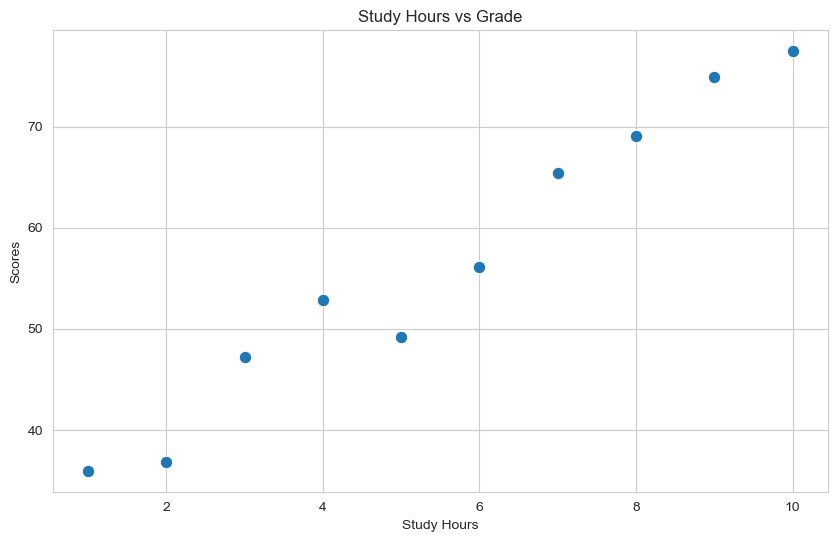

In [104]:
# rng: random number generator
rng = np.random.default_rng(42)

# generate data
max_hours = 10
study_hours = np.arange(1,max_hours+1)
#  y = 30 + 5x + noise
exam_scores = 30 + 5 * study_hours + rng.normal(0, 3, max_hours)

# plot
df = pd.DataFrame({'X': study_hours, 'y': exam_scores})
sns.scatterplot(data=df, x='X', y='y', s=80)
plt.xlabel('Study Hours')
plt.ylabel('Scores')
plt.title('Study Hours vs Grade')
plt.show()

### Step 2: Split Data into Training and Testing Sets

**Why?** We need to evaluate model performance on *unseen* data to ensure it generalises well.

In [105]:
from sklearn.model_selection import train_test_split

X = df[['X']] # features must be in a 2D array
y = df['y']   # single target 1D
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3 , random_state=42
)
print(f"X with {len(X_train)} samples (X_train) for training and {len(X_test)} for testing (X_test).")

X with 7 samples (X_train) for training and 3 for testing (X_test).


### Step 3: Linear Regression : create and Train the Model

In [106]:
from sklearn.linear_model import LinearRegression
# Create model instance
model = LinearRegression()
# Train (fit) the model
model.fit(X_train, y_train)
# Print model summary
print(f"Equation: y = {model.intercept_:.2f} + {model.coef_[0]:.2f} * x")

Equation: y = 31.88 + 4.57 * x


### Step 4: Make Predictions

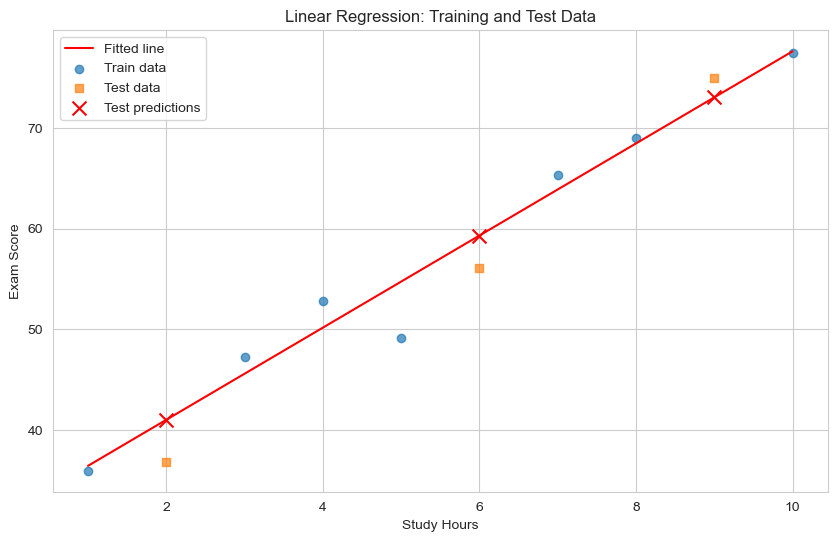

In [107]:
# Plot training and test data
df = pd.concat([
    X_train.assign(y=y_train, set="train"),
    X_test.assign(y=y_test, set="test")
], ignore_index=True)


# Fitted line
plt.plot(X, model.predict(X), 'r-', label='Fitted line')
# Predict on train and test separately
plt.scatter(X_train, y_train, label='Train data', alpha=0.7)
plt.scatter(X_test, y_test, label='Test data', marker='s', alpha=0.7)
# Optional: Mark predictions with X markers
plt.scatter(X_test, model.predict(X_test), marker='x', s=100,
            color='red', label='Test predictions', zorder=5)

# sns.lmplot(x='X', y='y', hue='sample', data=df,
#            #scatter_kws={'s': 80}  ,  # point size
#            ci=95,                    # confidence level
#            aspect=2)

plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Training and Test Data')
plt.legend();

### Step 5: Evaluate Model Performance

**Key Regression Metrics:**

1. **R² (Coefficient of Determination)**: Proportion of variance explained (0-1, higher is better)
2. **MAE (Mean Absolute Error)**: Average absolute difference between predicted and actual
3. **MSE (Mean Squared Error)**: Average squared difference (penalizes large errors more)
4. **RMSE (Root Mean Squared Error)**: Square root of MSE (same units as target)

In [108]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Predict on training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics
r2_train = r2_score(y_true=y_train, y_pred=y_train_pred)
r2_test = r2_score(y_true=y_test, y_pred=y_test_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)

print("=== Model Performance ===")
print("R² closer to 1 = better fit | Lower MAE/RMSE = smaller errors")
print()
print(f"R²:")
print(f"\tTrain: {r2_train:.3f}")
print(f"\tTest:  {r2_test:.3f}")
print(f"The model explains {r2_test*100:.1f}% of variance in test data.")
print()
print(f"Test Set Errors:")
print(f"\tMAE:  {mae_test:.2f} points")
print(f"\tRMSE: {rmse_test:.2f} points")


=== Model Performance ===
R² closer to 1 = better fit | Lower MAE/RMSE = smaller errors

R²:
	Train: 0.965
	Test:  0.957
The model explains 95.7% of variance in test data.

Test Set Errors:
	MAE:  3.10 points
	RMSE: 3.23 points


See [Regression metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics) for more detailes.

## Exercise 1: diamonds datasets

Build a linear regression model to predict diamond prices. Load the `diamonds` dataset, select appropriate features and target variable, split the data into training and test sets, train a LinearRegression model, make predictions, and evaluate the model using R². Interpret your results: what does the R² score tell you about your model's performance?

In [109]:
# Load diamonds dataset
diamond = sns.load_dataset('diamonds')

---

## Polynomial Regression

When relationships are non-linear, we can use polynomial features to capture curves.

$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + ...$$

**Example:** $2x^2 - 5x + 3 + \epsilon$

In [110]:
def poly_gen(range=(1, 10), size=30, seed=None):
    """
    Generate synthetic data: y = 2x² - 5x + 3 + noise
    params:
        range : X value range (start, end)
        size : Number of points
        seed : Random seed for reproducibility
    Returns : X, y
    """
    s, e = range
    rng = np.random.default_rng(seed)
    X_poly = np.linspace(s, e, size).reshape(-1, 1)  # Evenly spaced X values
    y_poly = 2 * X_poly ** 2 - 5 * X_poly + 3 + rng.normal(s, e, (size, 1))  # Quadratic + noise
    return X_poly, y_poly

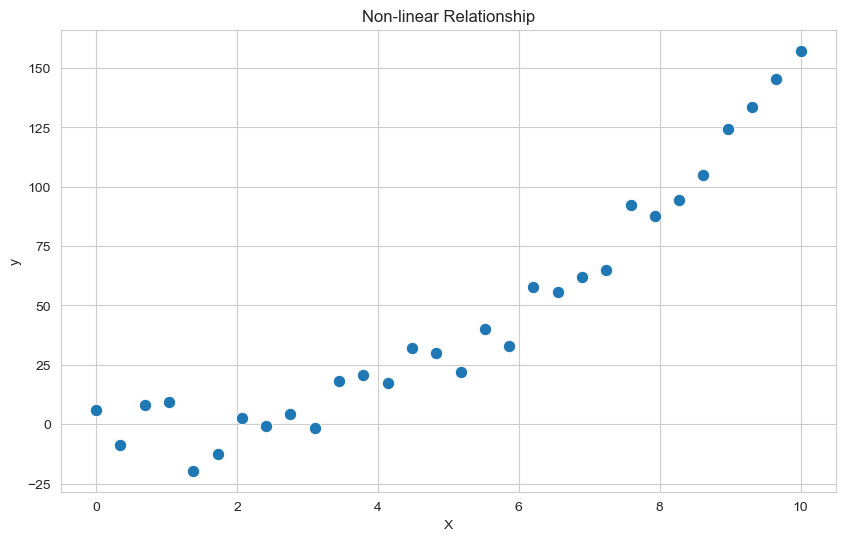

In [111]:
# Generate non-linear data
X_poly, y_poly = poly_gen(range=(0,10), size=30, seed=42)

# plot
df = pd.DataFrame( {'X': X_poly.ravel() , 'y' : y_poly.ravel()} )
sns.scatterplot(data=df, x='X', y='y', s=80)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Non-linear Relationship')
plt.show()

In the following  example, we use `PolynomialFeatures` to generate polynomial features and `LinearRegression` to fit a linear model using a `pipeline`. It illustrates the effect of different degrees, we compare the performance of different polynomial degrees on the same dataset.

**PolynomialFeatures** transforms input features into polynomial combinations up to a specified degree. For example, with degree=2 and input [x₁, x₂], it generates [1, x₁, x₂, x₁², x₁x₂, x₂²]. The `include_bias` parameter controls whether to include the constant term (1) as the first feature. When set to `False`, it excludes this column since `LinearRegression` already adds an intercept term by default, avoiding redundancy. Use `include_bias=True` only when working with models that don't automatically fit an intercept.

**make_pipeline** creates a sequential workflow that chains multiple transformers and a final estimator into a single object. It automatically applies each step in order: transformers use `fit_transform()` on training data and `transform()` on test data, while the final estimator uses `fit()` and `predict()`. For example, `make_pipeline(StandardScaler(), LogisticRegression())` first scales features, then trains the classifier—all with one `.fit()` call. This ensures transformations are applied consistently and prevents data leakage by fitting transformers only on training data.

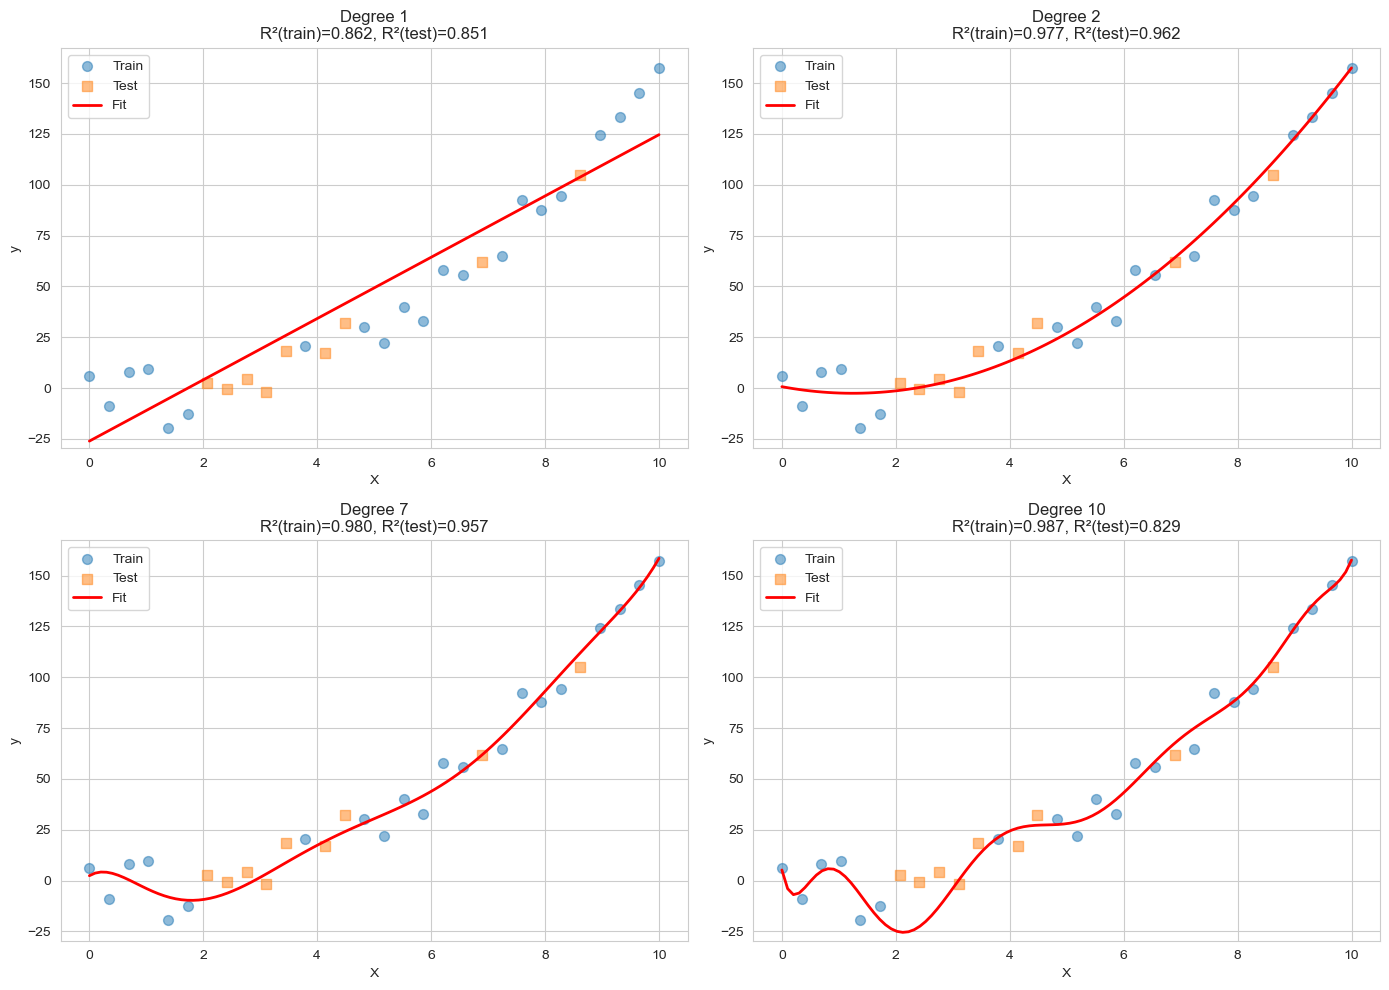

In [112]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# train/test split
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y_poly, test_size=0.3 , random_state=43
)

# Compare different polynomial degrees
degrees = [1, 2, 7, 10]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

X_range = np.linspace(X_poly.min(), X_poly.max(), 100).reshape(-1, 1)

for idx, degree in enumerate(degrees):
    # Create pipeline: PolynomialFeatures -> LinearRegression
    # include_bias=False to avoid redundant intercept

    model_poly = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False), # include_bias=False to avoid redundant intercept
        LinearRegression()
    )
    
    # Train model
    model_poly.fit(X_train_p, y_train_p)
    
    # Evaluate
    r2_train = model_poly.score(X_train_p, y_train_p)
    r2_test = model_poly.score(X_test_p, y_test_p)
    
    # Predict
    y_range_pred = model_poly.predict(X_range)
    
    # Plot
    axes[idx].scatter(X_train_p, y_train_p, alpha=0.5, label='Train', s=50)
    axes[idx].scatter(X_test_p, y_test_p, alpha=0.5, label='Test', s=50, marker='s')
    axes[idx].plot(X_range, y_range_pred, 'r-', linewidth=2, label='Fit')
    axes[idx].set_title(f'Degree {degree}\nR²(train)={r2_train:.3f}, R²(test)={r2_test:.3f}')
    axes[idx].set_xlabel('X')
    axes[idx].set_ylabel('y')
    axes[idx].legend()
    axes[idx].set_ylim([y_poly.min()-10, y_poly.max()+10])

plt.tight_layout()
plt.show()

- Degree 1 (linear): UNDERFITTING - too simple, low R² on both sets
- Degree 2: Good fit - captures curve, similar train/test R²
- Degree 7, 10: OVERFITTING - high train R², but unstable predictions

---

## Overfitting and Underfitting

| Problem | Characteristics | Solution                               |
|---------|----------------|----------------------------------------|
| **Underfitting** | Low train & test performance | Use more complex model, add features   |
| **Good Fit** | High train & test performance (similar) | Choose this model                      |
| **Overfitting** | High train, low test performance | Regularization, more data, simpler model |

### Adding New Data Points

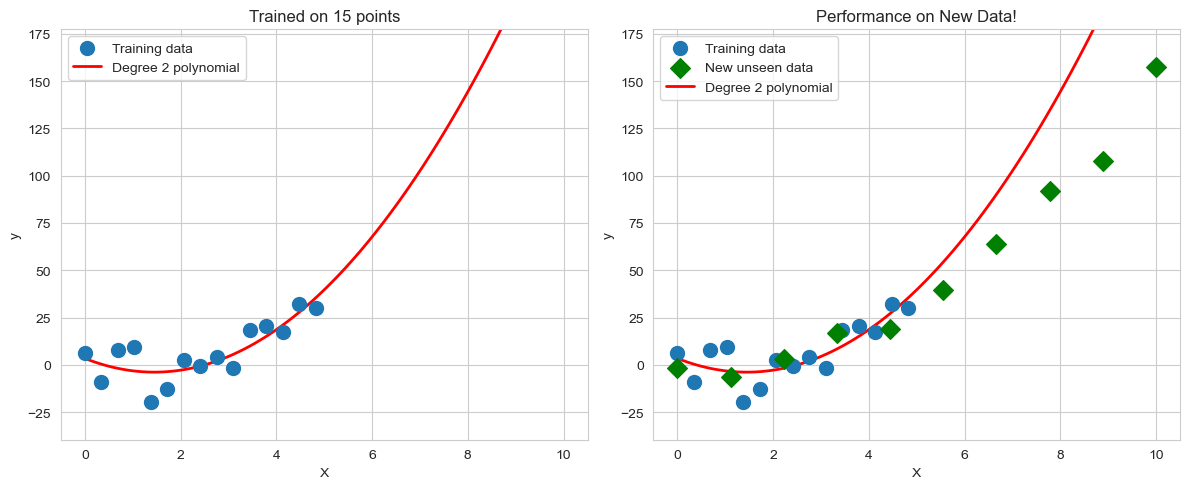

In [113]:
# Train high-degree polynomial on limited data

# 1)
X_limited = X_poly[:15]  # Only first 15 points
y_limited = y_poly[:15]

# 2)
degrees = [1, 2, 7, 10]
degree = degrees[1]

model_fit = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)

model_fit.fit(X_limited, y_limited)

# New unseen data points
X_new, y_new = poly_gen(range=(0,10), size=10, seed=45)
# Predictions
y_pred = model_fit.predict(X_range)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_limited, y_limited, s=100, label='Training data', zorder=3)
plt.plot(X_range, y_pred, 'r-', linewidth=2, label=f'Degree {degree} polynomial')
plt.title('Trained on 15 points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.ylim([y_poly.min()-20, y_poly.max()+20])

plt.subplot(1, 2, 2)
plt.scatter(X_limited, y_limited, s=100, label='Training data', zorder=3)
plt.scatter(X_new, y_new, s=100, color='green', marker='D', 
            label='New unseen data', zorder=3)
plt.plot(X_range, y_pred, 'r-', linewidth=2, label=f'Degree {degree} polynomial')
plt.title('Performance on New Data!')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.ylim([y_poly.min()-20, y_poly.max()+20])

plt.tight_layout()
plt.show()

The overfit model follows training data perfectly but makes poor predictions on new data (green points).

### Regularization: Controlling Model Complexity

**Regularization** prevents overfitting by adding a penalty term to the model's loss function that discourages large coefficient values. This technique is crucial when working with many features or when the model is too complex for the available data.

**Ridge Regression (L2)** adds the penalty $\lambda \sum_{j=1}^{p} \beta_j^2$ to shrink coefficients toward zero while keeping all features in the model. The parameter $\lambda$ (or `alpha` in sklearn) controls the regularization strength:
- Small $\lambda$ → weak penalty → complex model (risk of overfitting)
- Large $\lambda$ → strong penalty → simpler model (risk of underfitting)

**Lasso Regression (L1)** adds the penalty $\lambda \sum_{j=1}^{p} |\beta_j|$ which can shrink coefficients exactly to zero, effectively performing automatic feature selection. This is useful when you suspect only some features are truly relevant.

## Exercise 2: Polynomial Regression with Auto MPG Dataset

Build polynomial regression models to predict fuel efficiency (mpg) from horsepower using the Auto MPG dataset. Load MPG data, preprocess it (handle missing values), split into training and test sets, and fit polynomial models with degrees 1, 2, 3, and 5. Compare the R² scores for training and test sets to identify which polynomial degree best captures the relationship without overfitting. Visualize your results and interpret: which degree would you choose and why?


In [114]:
mpg = sns.load_dataset("mpg")
mpg.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB



---

# Part 2: Classification

We've explored regression for predicting continuous values. Now we shift to **classification**—predicting discrete categories. The same workflow applies: load data, split, train, evaluate. Let's use the classic Iris dataset to classify flower species.



## Iris dataset

The iris dataset contains 150 samples of iris species, `setosa`, `versicolor` and `virginica` with 50 observations per species. An iris has two 'features' `sepal` and `petal`, see figure below, and for each feature there are the length and width measurements.

- 150 samples of iris flowers
- 3 species: Setosa, Versicolor, Virginica (50 samples each)
- 4 features: sepal length, sepal width, petal length, petal width

<img src="https://content.codecademy.com/programs/machine-learning/k-means/iris.svg" alt="" width="600" align="center">

In [115]:
# Load data
iris_df = sns.load_dataset("iris")
print("sample of Iris dataset:")
print(iris_df.head())
print(f"\nshape: {iris_df.shape}\n")
print(f"{iris_df['species'].value_counts()}")

sample of Iris dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

shape: (150, 5)

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### Data Preparation : train/test

In [116]:
# Separate features and target
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X_iris = iris_df[feature_cols]
y_iris = iris_df['species']

# Split into train and test sets
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris,
    test_size=0.4,    # 40% test set
    random_state=42,  # for reproducibility
    stratify=y_iris   # ensure balanced class distribution

)

print(f"Training samples: {len(X_train_i)}")
print(f"Test samples: {len(X_test_i)}")
print(f"\nSpecies distribution in training set:\n{y_train_i.value_counts()}")

Training samples: 90
Test samples: 60

Species distribution in training set:
species
virginica     30
setosa        30
versicolor    30
Name: count, dtype: int64


### Label Encoding

Most ML algorithms require numerical labels, not strings.

In [117]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train_i)

# Transform labels
y_train_encoded = le.transform(y_train_i)
y_test_encoded = le.transform(y_test_i)

print("Label mapping:")
for idx, species in enumerate(le.classes_):
    print(f"{species:15} : {idx}")

Label mapping:
setosa          : 0
versicolor      : 1
virginica       : 2


### Feature Standardization (Scaling)

**Why standardize?**
- Many algorithms (SVM, KNN, Neural Networks) are sensitive to feature scales
- Standardization: $z = \frac{x - \mu}{\sigma}$ (mean=0, std=1)

**Important**: Fit scaler on training data only, then transform both train and test!

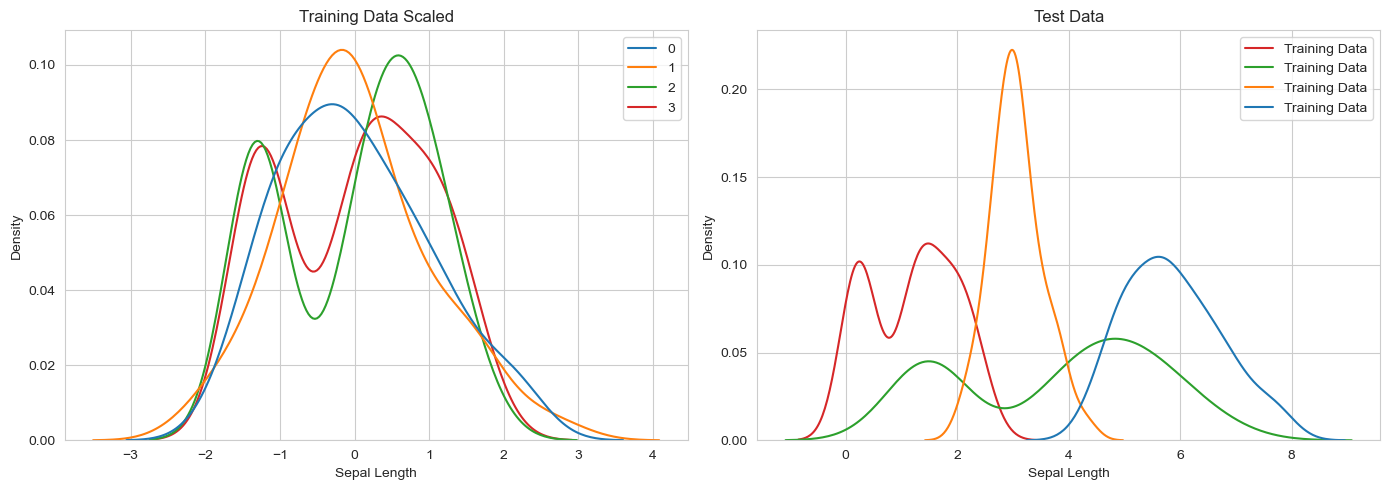

In [118]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_i)    #  derive mean and std from training data

# Transform both sets
X_train_scaled = scaler.transform(X_train_i)
X_test_scaled = scaler.transform(X_test_i)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(X_train_scaled,  ax=axes[0])
sns.kdeplot(X_train_i, label='Training Data', ax=axes[1])
axes[0].set_title('Training Data Scaled')
axes[1].set_title('Test Data')
axes[0].set_xlabel('Sepal Length')
axes[0].set_ylabel('Density')
axes[1].set_xlabel('Sepal Length')
axes[1].set_ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

### Exercise 3:

1) Implement an encoder using pandas
- Split iris data (60/40)
- Encode labels manually (without LabelEncoder) using pandas
- Verify encoding worked correctly

2) Implement train_test_split.

---

## Support Vector Machine (SVM)

**Intuition**: Find the hyperplane that best separates classes with maximum margin.

**Key Parameters**:
- `kernel`: Type of decision boundary ('linear', 'rbf', 'poly')
- `C`: Regularization parameter (smaller C = simpler model)
- `gamma`: Kernel coefficient (for 'rbf', 'poly')

In [119]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create and train SVM classifier ; Support Vector Classification (SVC)
svm_model = SVC(random_state=42)  # default kernel='rbf'
svm_model.fit(X_train_scaled, y_train_encoded)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate
accuracy = accuracy_score(y_test_encoded, y_pred_svm)
print(f"SVM Classification Accuracy: {accuracy:.2f} ({accuracy*100:.1f}%)")

SVM Classification Accuracy: 0.95 (95.0%)


### Confusion Matrix

Shows where the model makes mistakes:
- Diagonal = correct predictions
- Off-diagonal = misclassifications

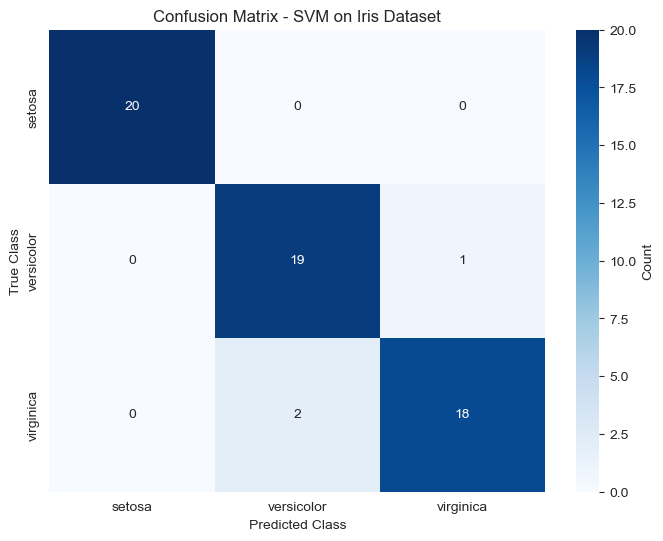

In [120]:
# Compute confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred_svm)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix - SVM on Iris Dataset')
plt.show()

### Classification Report

**Key Metrics**:
- **Precision**: Of all predicted positives, how many are correct? $\frac{TP}{TP + FP}$
- **Recall**: Of all actual positives, how many did we find? $\frac{TP}{TP + FN}$
- **F1-Score**: Harmonic mean of precision and recall $2 \cdot \frac{precision \cdot recall}{precision + recall}$
- **Support**: Number of samples in each class

In [121]:
print("=== Classification Report - SVM ===")
print(classification_report(y_test_encoded, y_pred_svm, 
                          target_names=le.classes_))

print("Understanding the metrics:")
print("- Precision: 'When model predicts X, how often is it correct?'")
print("- Recall: 'Of all actual X samples, how many did model find?'")
print("- F1-score: Balance between precision and recall")

=== Classification Report - SVM ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        20
  versicolor       0.90      0.95      0.93        20
   virginica       0.95      0.90      0.92        20

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60

Understanding the metrics:
- Precision: 'When model predicts X, how often is it correct?'
- Recall: 'Of all actual X samples, how many did model find?'
- F1-score: Balance between precision and recall


### Model : logistic regression

We import the class `Linear Regression` from the `linear_model` subsection of the `sklrean`:

In [122]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)         # model object
model.fit(X_train_scaled, y_train_encoded)         # train the model in the training set
y_pred = model.predict(X_test_scaled)              # make predictions on the test set
logreg_accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"LogisticRegression Classification Accuracy: {logreg_accuracy:.2f} ({logreg_accuracy*100:.1f}%)")

LogisticRegression Classification Accuracy: 0.93 (93.3%)


See [Metrics](https://scikit-learn.org/stable/modules/model_evaluation.html) for more on prediction quality evaluation.

### Evaluate SVM using cross-validation

In [123]:
from sklearn.model_selection import cross_val_score

svm_cv_scores = cross_val_score(
    #SVC(),
    LogisticRegression(),
    X_train_scaled, y_train_encoded,
    cv=5
)
print("5-Fold Cross-Validation Results (SVM):")
print(f"Fold scores: {svm_cv_scores}")
print(f"Mean accuracy: {svm_cv_scores.mean():.4f} ± {svm_cv_scores.std():.4f}")

5-Fold Cross-Validation Results (SVM):
Fold scores: [1.         1.         1.         0.88888889 0.94444444]
Mean accuracy: 0.9667 ± 0.0444


In [124]:
# 1) full_train, class_encoded
scaler = StandardScaler()
full_train = scaler.fit_transform(iris_df[feature_cols])
# Encode the label
le =LabelEncoder()
species_encoded = le.fit_transform(iris_df['species'])
# 2) X_train_scaled, y_train_encoded



### Hyperparameter tuning - Grid Search

We achieved high accuracy on Iris classification with default settings, real-world problems often require **hyperparameter tuning** to optimize performance. `GridSearchCV` automates this process by systematically testing different parameter combinations (e.g., regularization penalties L1/L2, complexity parameter C) using cross-validation, then selecting the best-performing configuration. It takes a parameter grid (dictionary) and a `cv` value specifying the number of folds, making it easy to find optimal settings without manual trial-and-error.


In [125]:
from sklearn.model_selection import GridSearchCV

# Standardise the features on the full data set
scaler = StandardScaler()
full_train = scaler.fit_transform(X_iris)
le =LabelEncoder()
species_encoded = le.fit_transform(y_iris)

gs_params = {'C': [0.001, 0.01, 0.1, 0.5, 1, 2, 5],                       # C = 1/lambda
             'solver' : [ 'newton-cg', 'newton-cholesky', 'lbfgs']
            }
gs = GridSearchCV(model, gs_params, cv=5)
gs.fit(full_train, species_encoded);

Using the attribute `.best_params_` we can check which values of the parameters were selected by the `GridSearch` algorithm as optimal:

In [126]:
gs.best_params_

{'C': 2, 'solver': 'newton-cg'}

The attribute `.best_score_` allows us to check what is the level of the classification accuracy after the best values of model parameters (`best_params_`) have been applied:

In [127]:
# Mean cross-validated score of the best_estimator
print(f"best score {gs.best_score_:.3f} with {gs.best_params_}")

best score 0.967 with {'C': 2, 'solver': 'newton-cg'}


The attribute `.cv_results_` contains all the information about the cross-validation procedure, including the mean and standard deviation of the scores for each parameter combination.

In [128]:
gs_df = pd.DataFrame(gs.cv_results_)
gs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   mean_fit_time      21 non-null     float64
 1   std_fit_time       21 non-null     float64
 2   mean_score_time    21 non-null     float64
 3   std_score_time     21 non-null     float64
 4   param_C            21 non-null     float64
 5   param_solver       21 non-null     str    
 6   params             21 non-null     object 
 7   split0_test_score  21 non-null     float64
 8   split1_test_score  21 non-null     float64
 9   split2_test_score  21 non-null     float64
 10  split3_test_score  21 non-null     float64
 11  split4_test_score  21 non-null     float64
 12  mean_test_score    21 non-null     float64
 13  std_test_score     21 non-null     float64
 14  rank_test_score    21 non-null     int32  
dtypes: float64(12), int32(1), object(1), str(1)
memory usage: 2.5+ KB
